<a href="https://colab.research.google.com/github/Tedodor423/bms-collab-notebooks/blob/main/stats/3.3_ttest/3.3.8_ttest_independentSamples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Independent samples t-test

*An independent-samples $t$-test tests whether the means of two independent (or unpaired) groups are different.*

### Set up Python libraries

As usual, run the code cell below to import the relevant Python libraries

In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Example: Apple Trees and Fertiliser

<img src="https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook/main/images/appletree.jpg" width=30% >

A researcher is interested in whether fertiliser affects the weight of apples produced by apple trees.

Data are collected on the average apple weight (in grams) from each of 20 apple trees. Ten of the trees received **MiracleGro** fertiliser, and the other ten received **Brand X** fertiliser.

**Question:** test the hypothesis that trees given MiracleGro produce heavier apples than trees given Brand X.

*Notes:*
- This is an **independent-samples** design: different trees are assigned to each fertiliser, and there is nothing that inherently links the trees.
- If the data are approximately Normally distributed with similar variability in each group, an **independent-samples $t$-test** is appropriate.
- The hypothesis is **directional**, which justifies a **one-sided** test.

*Practical steps*
1. Inspect the data to check for extreme outliers and approximate Normality
2. State the formal hypotheses.  
3. Report the descriptive statistics (mean, standard deviation, and sample size for each group).  
4. Run the independent-samples $t$-test.  
5. Draw conclusions.


### 1. Inspect the data

The data are provided in a text (.csv) file.

Let's load the data as a Pandas dataframe, and plot them to get a sense for their distribution (is it normal?, are there any outliers?)

In [ ]:
# load the data and have a look
apples = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/AppleWeights.csv')
apples

,Fertilizer,meanAppleWeight
0,BrandX,172
1,BrandX,165
2,BrandX,175
3,BrandX,164
4,BrandX,165
5,BrandX,157
6,BrandX,183
7,BrandX,186
8,BrandX,191
9,BrandX,173


**Plot the data**

Let's plot the data and see if they look Normally distributed.

As we saw in the session on plotting, a good choice here will be a KDE plot (to get an estimate of the shape of the distribution) and a rug plot (individual data values as the KDE plot is based on only a small sample)

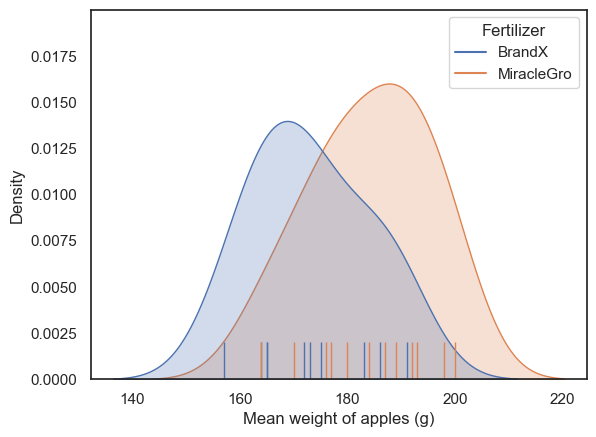

In [ ]:
sns.kdeplot(data=apples, x='meanAppleWeight', hue='Fertilizer', fill=True)
sns.rugplot(data=apples, x='meanAppleWeight',  hue='Fertilizer', height=0.1)
plt.xlabel("Mean weight of apples (g)", fontsize = 12)
plt.ylabel("Density", fontsize = 12)

plt.show()

It looks like both distributions are unimodal but a bit skewed.

Typically, it would be hard to say if the data are really non-normal due to the small number
of data points (the apparent skew could be a fluke). By default, I would err on the side of caution and use a non-parametric test.

However, in this particular case I am confident that the data in each sample are drawn from a normal distribution
because each data point represents the mean of a large sample (the weights of all apples on one tree)
and such means are always normally distributed due to the Central Limit theorem.
There is a video explaining why here.

So we can go ahead and use a t-test.

### 2. Hypotheses

$\mathcal{H_o}$: the mean weight of apples is the same for trees fertilized with MiracleGro and Brand X

$\mathcal{H_a}$: the mean weight of apples is greater for trees fertilized with MiracleGro
    
This is a one tailed test as the manufacturers of MiracleGro are only looking for an effect in one direction
(evidence that MiracleGro is better!)

We will test at the $\alpha = 0.05$ significance level

### 3. Descriptive statistics

First, we obtain the relevant desriptive statistics. By relevant, I mean the ones that go into the equation for the t-test:


$ t = \frac{\bar{x_1} - \bar{x_2}}{s \sqrt{\frac{1}{n_1}+\frac{1}{n_2}}} $

This would be the sample means $\bar{x_1}$ and $\bar{x_2}$, and the standard deviations for both samples (these feed into the pooled standard deviation $s$) and the sample size $n$.

Remember, <tt>apples</tt> is our original Pandas dataframe:

In [ ]:
display(apples)

,Fertilizer,meanAppleWeight
0,BrandX,172
1,BrandX,165
2,BrandX,175
3,BrandX,164
4,BrandX,165
5,BrandX,157
6,BrandX,183
7,BrandX,186
8,BrandX,191
9,BrandX,173


We can use `df.describe()` method in `pandas` together with `df.groupby()` in order to obtain the descriptive statistics separately for each fertilizer type.


In [ ]:
apples.groupby(["Fertilizer"]).describe()

meanAppleWeight                                               \
                     count        mean        std    min     25%    50%   
Fertilizer                                                                
BrandX                10.0  173.100000  10.867382  157.0  165.00  172.5   
MiracleGro            12.0  184.166667  11.101460  164.0  176.75  185.5   

                           
               75%    max  
Fertilizer                 
BrandX      181.00  191.0  
MiracleGro  192.25  200.0

The mean apple weight for trees treated with **Brand X** was 173.1 g (SD = 10.9 g, n = 10), whereas the mean apple weight for trees treated with **MiracleGro** was 184.2 g (SD = 11.1 g, n = 12).

It does look like the mean weight of apples from the MiracleGro trees is higher, but is the difference statistically significant?

### 4. Carry out the test

We carry out the test using the function `stats.ttest_ind()` from `scipy.stats`.

The inputs to `stats.ttest_ind()` are:
- the two independent samples to be compared (the values in the `meanAppleWeight` column from the Pandas DataFrames `apples_MiracleGro` and `apples_BrandX`);
- the argument `alternative='greater'`, which specifies a one-tailed test in which the mean apple weight for trees treated with **MiracleGro** is expected to be greater than that for trees treated with **Brand X**.

The outputs are the value of the test statistic ($t = 2.35$) and the associated p-value ($p = 0.0146$). Because this p-value is less than our chosen significance level ($\alpha = 0.05$), we conclude that there is a statistically significant difference between the groups.


In [ ]:
stats.ttest_ind(apples.query('Fertilizer=="MiracleGro"').meanAppleWeight,
                apples.query('Fertilizer=="BrandX"').meanAppleWeight,
                alternative='greater')

Ttest_indResult(statistic=2.350347501385599, pvalue=0.014564862730138283)

**Degrees of freedom**

In a scientific write-up we also need to report the degrees of freedom of the test. This tells us how many observations (data-points) the test was based on, corrected for the number of means we had to estimate from the data in order to do the test.

In the case of the independent samples t-test $df = n_1 + n_2 - 2$ so in this case, df=(10+12-2)=20 and we can report out test results as:

$t(20) = 2.35, p=0.0146$ (one-tailed)

### 5. Interpretation

Our t value of 2.35 means that the difference in mean apple weights between MiracleGro and BrandX trees is 2.35 times the standard error (where $ SE = s \sqrt{\frac{1}{n_1}+\frac{1}{n_2}}$).

Such a large difference (in the expected direction) would occur 0.0146 (1.46%) of the time due to chance if the null hypothesis were true (if MiracleGro was really no better than Brand X), hence the p value of 0.0146.

This diagram shows the expected distribution of t-values if the null were true, with our obtained t-value marked:

<img src="https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook/main/images/ttestApples.png" width=50% alt="There should be a picture of the t-distribution here" >

### 5. Draw conclusions

As p<0.05 we conclude that the mean weight of apples on trees fertilized with MiracleGro is indeed greater than the mean weight of apples on trees fertilized with Brand X

## Write-up
<br>

<div style = "    padding-top: 10px;
    padding-bottom: 10px;
    padding-left: 10px;
    padding-right: 10px;
    box-shadow: 0px 8px 16px 0px rgba(0,0,0,0.2);
    vertical-align: middle;">
    
Above, I walked you through how to run the t-test and why we make different choices.
    
In this section we revisit the analysis, but here we practice writing up our analysis in the correct style for a scientific report.
    
Replace the XXXs with the correct values!    

</div>

<br>

    
We tested the hypothesis that the mean weight of apples produced by trees fertilized with MiracleGro was higher than for trees fertilized with Brand X.

The mean apple weight was measured for each of XX trees fertilized with MiracleGro (mean of mean apple weights over XX trees XXX.Xg, sd of mean apple weights over 100 trees, XXX.Xg) and XX trees fertilized with Brand X (mean over XX trees XXX.Xg, sd XXX.Xg).


In [ ]:
apples = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/AppleWeights.csv')
apples.groupby(["Fertilizer"]).describe()

meanAppleWeight                                               \
                     count        mean        std    min     25%    50%   
Fertilizer                                                                
BrandX                10.0  173.100000  10.867382  157.0  165.00  172.5   
MiracleGro            12.0  184.166667  11.101460  164.0  176.75  185.5   

                           
               75%    max  
Fertilizer                 
BrandX      181.00  191.0  
MiracleGro  192.25  200.0

Theoretical considerations suggest that data for each group of trees should be drawn from a normal distribution: as individual data points were themselves the means of large samples (all apples from a given tree), these data points should follow a normal distribubtion due to the Central Limit Theorem. This was supported by a plot of the data:

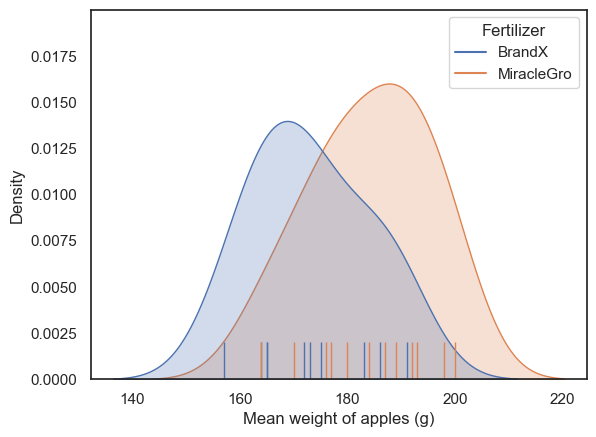

In [ ]:
sns.kdeplot(data=apples, x='meanAppleWeight', hue='Fertilizer', fill=True)
sns.rugplot(data=apples, x='meanAppleWeight',  hue='Fertilizer', height=0.1)
plt.xlabel("Mean weight of apples (g)", fontsize = 12)
plt.ylabel("Density", fontsize = 12)

plt.show()

An independent samples t-test was therefore used to compare the means (alpha = XXX, XXX-tailed).

In [ ]:
stats.ttest_ind(apples.query('Fertilizer=="MiracleGro"').meanAppleWeight,
                apples.query('Fertilizer=="BrandX"').meanAppleWeight,
                alternative='greater')

TtestResult(statistic=np.float64(2.350347501385599), pvalue=np.float64(0.014564862730138283), df=np.float64(20.0))

The weight of apples from the trees fertilized with MiracleGro was indeed found to be significantly higher: t(18) = 2.35, p=0.0146.

## Exercises

1. Can you work out how to run a two-tailed test on the data?
* Info on the possible values for 'alternative' can be found on the
<a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html"> scipy reference page </a>

2. What happens to the p value if you run a two tailed test instead of one tailed? Is it more or less significant? Why?